![interpreto_banner](../../assets/img/interpreto_banner.png){ style="display:block; max-width:100%; height:auto; margin:0 auto;" }

# Explainability for Bias Analysis in NLP Models

In this notebook, we explore how explainability methods in `interpreto` can help us analyze biases in Natural Language Processing models.

Biases in NLP models are often difficult to observe directly. A model may achieve good predictive performance while relying on undesirable correlations, such as associations between gender markers and occupations. Explainability provides tools to inspect model behavior beyond accuracy: it allows us to study which input tokens are important, what information is encoded in internal representations, and how abstract concepts are used by the model.

The notebook is divided into two main parts.

First, we study a **classification task** using the BIOS dataset. The goal is to predict a person’s profession from a short biography. This setting is particularly useful for studying gender bias, because some professions may be spuriously associated with gendered cues in the input.

Second, we study a **translation task** from English to French. In this part, the objective is not to automatically detect bias, but rather to use attribution methods to better understand which parts of the input influence the model when it produces a masculine translation.

Throughout the notebook, we focus on three complementary families of explainability methods:

- **Attributions**, which identify the most influential input tokens.
- **Probes**, which test whether sensitive information is encoded in model representations.
- **Concept-based methods**, which analyze model behavior through higher-level human-interpretable concepts.


*author: Fanny Jourdan, Antonin Poché*

# 1. Classification Task

In this first part, we focus on a text classification task.

We use the BIOS dataset, which contains short biographies associated with professional labels. The model receives a biography as input and predicts the profession of the person described in the text. Because biographies often contain gendered words, names, pronouns, or stereotypical descriptions, this task is a useful case study for analyzing gender bias in NLP models.

We use a `roberta-bios-biased`, RoBERTa-based classifier fine-tuned on a biased version of BIOS. The training procedure deliberately amplifies correlations between gender and profession: for professions where one gender is highly over-represented (more than 65%), the training data keeps only examples from the majority gender. This creates a model that is expected to rely more strongly on gender/profession correlations.

The objective of this section is to use explainability methods to answer the following questions:

1. Which words does the model rely on when predicting a profession?
2. Is gender information encoded in the model’s internal representations?
3. Can we analyze the model through interpretable concepts related to gender used for the prediction?

We will study these questions using three complementary approaches: attributions, probes, and concepts.

In [2]:
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from torch.nn import functional as F
from tqdm.notebook import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer

In [3]:
model_name = "Fannyjrd/roberta-bios-biased"

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()

dataset = load_dataset("LabHC/bias_in_bios")

In [4]:
classes_names = [
    "accountant",
    "architect",
    "attorney",
    "chiropractor",
    "comedian",
    "composer",
    "dentist",
    "dietitian",
    "dj",
    "filmmaker",
    "interior_designer",
    "journalist",
    "model",
    "nurse",
    "painter",
    "nurse",
    "painter",
    "paralegal",
    "pastor",
    "personal_trainer",
    "photographer",
    "physician",
    "poet",
    "professor",
    "psychologist",
    "rapper",
    "software_engineer",
    "surgeon",
    "teacher",
    "yoga_teacher",
]

gender_names = ["male", "female"]

## 1.1 Attributions

Attribution methods aim to explain a model prediction by assigning an importance score to each input token.

In the context of our profession classification task, attributions allow us to inspect which words in a biography contribute the most to the predicted profession. This is useful for bias analysis because it helps us identify whether the model relies on legitimate professional evidence, such as skills, degrees, or job-related activities, or on potentially biased cues, such as gendered pronouns, names, or stereotypical descriptions.

For a more detailed analysis of bias, we first run the model on the test set to obtain the label of the predicted class. We then do attribution on the true label and the predicted label.
For our example, we restrict ourselves only to cases where the model did not predict the correct label. 

In [5]:
BATCH_SIZE = 64
MAX_LENGTH = 256
test_set = dataset["test"].select(range(10_000))

preds = []

for i in tqdm(range(0, len(test_set), BATCH_SIZE)):
    texts = test_set[i : i + BATCH_SIZE]["hard_text"]

    inputs = tokenizer(texts, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors="pt").to(device)

    with torch.no_grad():
        logits = model(**inputs).logits
        batch_preds = logits.argmax(dim=-1).cpu().tolist()

    preds.extend(batch_preds)

  0%|          | 0/157 [00:00<?, ?it/s]

In [6]:
# This list contains the IDs of some examples that are female and misclassified,
# where the model predicted a predominantly female occupation instead of the actual occupation.
ids_error = [
    107,
    155,
    1062,
    1083,
    1470,
    1492,
    1511,
    1536,
    1735,
    2129,
    2160,
    2426,
    2435,
    2449,
    2708,
    3063,
    3752,
    4271,
    4280,
    4364,
    4467,
    4547,
    4667,
    4699,
    4873,
    5103,
    8523,
]  # others ids if you predict all the test set: 26534,26572,26986,27126,30337,30528,30576,30612,30641,30829,31176,31219,31284]

In [7]:
from interpreto import Lime, plot_attributions

explainer = Lime(model, tokenizer, n_perturbations=200)

for i in range(3):
    sentence = dataset["test"]["hard_text"][ids_error[i]]
    gender = dataset["test"]["gender"][ids_error[i]]
    true_class = dataset["test"]["profession"][ids_error[i]]
    predicted_class = preds[ids_error[i]]
    # Compute the attributions on a given sentence
    attributions = explainer(sentence, targets=torch.tensor([[true_class, predicted_class]]))

    # Visualize the attributions
    viz_classes_names = classes_names.copy()
    viz_classes_names[true_class] = "Label: " + classes_names[true_class]
    viz_classes_names[predicted_class] = "Predicted: " + classes_names[predicted_class]
    plot_attributions(attributions[0], classes_names=viz_classes_names)

## 1.2 Probing gender biases (supervised)

In this section we learn a concept direction for gender and estimate predictions sensitivity to it.

### 1.2.1 Compute activations

We split the model between the encoder $enc$ and the classification head $cls$ thanks to the `splitter`. Then compute the activations $z$ as the output of the encoder (they correspond to the [CLS] token).

$f = cls \circ enc$

$z = enc(x)$

In [8]:
from interpreto import SplitterForClassification

# Get inputs and gender label from the dataset
train_inputs = list(dataset["train"]["hard_text"])
train_genders = torch.tensor(dataset["train"]["gender"])
test_inputs = list(dataset["test"]["hard_text"])
test_genders = torch.tensor(dataset["test"]["gender"])

# instantiate the splitter from the model
splitter = SplitterForClassification(
    model,
    tokenizer=tokenizer,
    device_map=device,
    batch_size=512,
)

# compute their activations
train_acts, train_occ_preds = splitter.get_activations(
    train_inputs, tqdm_bar=True, forward_kwargs={"truncation": True}
)
test_acts, test_occ_preds = splitter.get_activations(test_inputs, tqdm_bar=True, forward_kwargs={"truncation": True})

100%|██████████| 194/194 [02:50<00:00,  1.14it/s]


### 1.2.2 Train and evaluate the gender probe

We use a linear SVM as in the original CAV paper [1].

$$
s(z) = w^T z + b
$$

[1] Kim et al. ICML 2018, Interpretability Beyond Feature Attribution: Quantitative Testing with Concept Activation Vectors (TCAV)

In [9]:
from interpreto.concepts.probes import LinearSVMProbe, ProbeExplainer

# Training the probe classifier
probe = LinearSVMProbe(lr=1e-2, max_iter=200, normalization=None)

probe_explainer = ProbeExplainer(splitter, probe)
probe_explainer.to(device)

probe_explainer.fit(train_acts.to(device), train_genders.float().unsqueeze(1).to(device))

# Validating the probe performance
with torch.no_grad():
    test_scores = probe_explainer.activations_to_concepts(test_acts.to(device))
test_gender_preds = (test_scores.squeeze(1) > 0).long()
accuracy = (test_gender_preds == test_genders.cuda()).float().mean().item()
print(f"test gender probe accuracy: {accuracy:.3f}")

test gender probe accuracy: 0.995


### 1.2.3 CAV and TCAV

We extract the CAV (Concept Activation Vector) as the probe weights. Then apply TCAV. TCAV basically compute how sensible are the outputs to perturbations along the CAV. Therefore, how sensible are professions predictions to gender.

CAV: $w$

TCAV: $\nabla_z cls(z) \cdot w$

In [10]:
# Extracting and normalize the gender vector (cpt, d)
cav = probe_explainer.concept_model.weight.detach().squeeze()
ncav = cav / cav.norm()

# compute the activations to output gradients
gradients_list = splitter._get_concept_output_gradients(
    inputs=test_acts,
    activations_to_concepts=lambda z: z,
    concepts_to_activations=lambda z: z,
    concepts_x_gradients=False,
)
gradients = torch.stack(gradients_list).squeeze().cuda()  # (n, cls, d)

# tcav is a projection of gradients on the CAV direction
tcav = gradients @ ncav  # (n, cls)

### 1.2.4 Aggregate TCAV scores across the dataset

For each class, we compute the ratio of samples were the TCAV scores show masculine or feminine sensitivity.

However, we do not want to include low TCAV scores in these ratios, thus introducing a neutral zone.

To define which scores are low, we define a threshold as 95th percentile of the TCAV scores distribution for each class. Note that this 95th percentile is an arbitrary choice which drastically impact the results.

In [11]:
# Define a sensitivity threshold
torch.manual_seed(0)
random_directions = F.normalize(torch.randn(cav.shape[0], 100, device=device), dim=0)  # (d, 100)
t_random = gradients @ random_directions  # (n, cls, 100)
threshold = torch.quantile(t_random.abs().permute(1, 0, 2).flatten(1, 2), 0.95, dim=-1)  # (cls,)

# aggregate gender sensitivity between masculine/neutral/feminine
masc_rates = (tcav <= -threshold).float().mean(0)
fem_rates = (tcav >= threshold).float().mean(0)
neutral_rates = 1 - masc_rates - fem_rates

### 1.2.5 Visualization of Gender biases

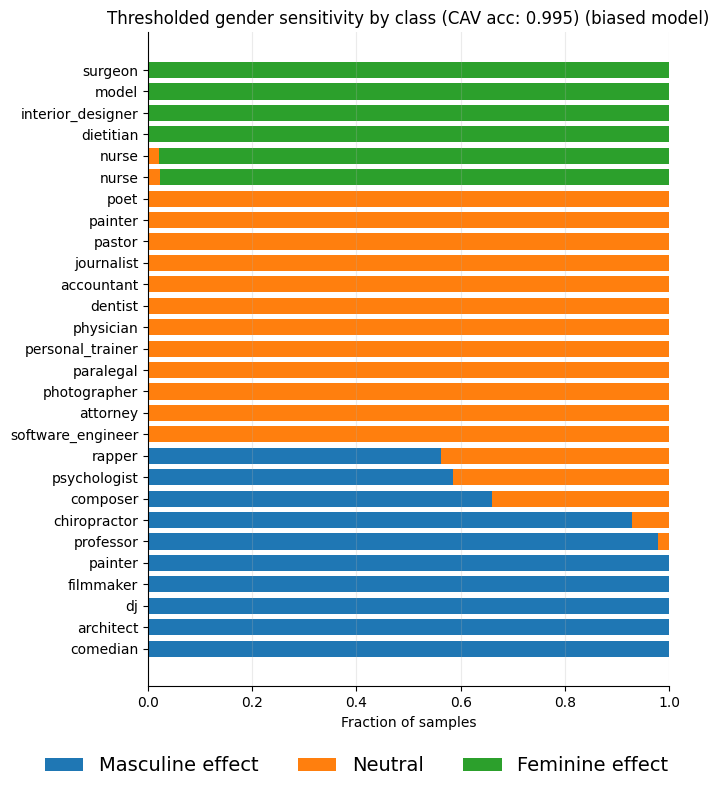

In [12]:
# Sort by net direction
score = fem_rates - masc_rates
order = torch.argsort(score)

masc = masc_rates[order].detach().cpu()
neutral = neutral_rates[order].detach().cpu()
fem = fem_rates[order].detach().cpu()
names = [classes_names[i.item()] for i in order]

y = torch.arange(len(names))

fig, ax = plt.subplots(figsize=(7, 8))

# Standard stacked bars: each row spans [0, 1]
left_masc = torch.zeros_like(masc)
left_neutral = masc
left_fem = masc + neutral

ax.barh(y, masc, left=left_masc, height=0.75, label="Masculine effect")
ax.barh(y, neutral, left=left_neutral, height=0.75, label="Neutral")
ax.barh(y, fem, left=left_fem, height=0.75, label="Feminine effect")

ax.set_yticks(y)
ax.set_yticklabels(names)

ax.set_xlim(0, 1)
ax.set_xlabel("Fraction of samples")
ax.set_title(f"Thresholded gender sensitivity by class (CAV acc: {accuracy:.3f}) (biased model)")

ax.grid(axis="x", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.4, -0.08), ncol=3, fontsize=14)

plt.tight_layout()
plt.show()

## 1.3 Unsupervised concepts discovery

In this section we do not have labels for the concepts, thus, we learn them in an unsupervised way. They correspond to patterns in the activations. Once learnt, we interpret and estimate their importance for each class.

### 1.3.1 Compute activations

This has already been done in 1.2.1. So we reuse these elements.

### 1.3.2 Train the concept model

We use the SemiNMF (a relaxed version of the Non-negative Matrix Factorization) to learn the concepts. It decomposes activations $A = enc(X)$ into a product of concept activations $Z$ and concept vectors $W$:

$$
A = ZW
$$

In [13]:
from interpreto.concepts import SemiNMFConcepts

# instantiate from the splitter
concept_explainer = SemiNMFConcepts(splitter, nb_concepts=50, device=device)

# learn concepts as patterns in the activations
concept_explainer.fit(train_acts.to(device), max_iter=500)

### 1.3.3 Interpret concepts

Concepts are currently abstract directions in the activation space, e need to assign them meaning. For each concept $cpt$, we compute the topk activating words, said differently, the words which aligns the most to the concept direction in the activation space.

$$
topk(cpt) = topk_X\ enc(x) \cdot W_{cpt}
$$


In [14]:
from interpreto.concepts.interpretations import TopKInputs

topk = TopKInputs(
    concept_explainer=concept_explainer,
    k=5,
    use_unique_words=3,  # extend up to 3-words ngrams
    unique_words_kwargs={
        "count_min_threshold": max(1, round(len(test_inputs) * 0.002)),  # present in at least 0.2% of the inputs
        "lemmatize": True,
    },
)
interpretations = topk.interpret(inputs=test_inputs)
interpretations = {str(k): list(v.keys()) for k, v in interpretations.items()}

### 1.3.4 Estimate concepts importance

Concepts might be present but not relevant for the predictions. This step evaluates the global importance of concepts with respect to each class.

The importance is given by the average (over samples) of the concepts to outputs gradients weighted by the concepts activations:
$$
mean(\nabla_z cls(ZW) \cdot Z)
$$

In [15]:
gradients_list = concept_explainer.concept_output_gradient(
    test_acts, targets=None, tqdm_bar=True, normalization=False, concepts_x_gradients=True
)
importances = torch.stack(gradients_list).squeeze().mean(0).cpu()  # (cls, cpt)

100%|██████████| 194/194 [00:12<00:00, 15.55it/s]


### 1.3.5 Visualize concepts

You need to click on the classes names to the the relevant concepts.

In [16]:
from interpreto import plot_concepts

plot_concepts(classes_names=classes_names, concepts_importances=importances, concepts_labels=interpretations, top_k=5)

# 2. Translation Task

In the second part of the notebook, we move from classification to translation.

We study an English-to-French translation task using a generation model. This setting raises a different kind of question. In English, majority of the job title are gender neutral such as “the doctor”, “the nurse”. In French, however, many occupations, adjectives, and determiners require gender marking. As a result, a translation model often has to produce a masculine, feminine, or inclusive form, even when the English sentence does not explicitly specify gender.

The FairTranslate paper [1] (which introduces an English-French dataset for evaluating gender bias in machine translation) shows that translation models tend to produce masculine forms more often than feminine or inclusive forms.

In this part we want to understand: **How does the model work when it has this bias?**

[1] Jourdan et al, FAccT 2024, FairTranslate: An English-French Dataset for Gender Bias Evaluation in Machine Translation by Overcoming Gender Binarity.

Download a generation model from HuggingFace.

In [17]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "meta-llama/Llama-3.2-1B-Instruct"

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model.eval()
print()

Construct inputs and artificial outputs. There is one feminine and one masculine output.

In [18]:
english_sentence = "The surgeon has led an emergency operation. She made crucial decisions in record time."

prompt = f"Traduit: {english_sentence} \n"

target_masc = "Le chirurgien a mené une opération d'urgence. Il a pris des décisions cruciales en un temps record."
target_fem = "La chirurgienne a mené une opération d'urgence. Elle a pris des décisions cruciales en un temps record."

Attribute output words to previous ones.

In [ ]:
from interpreto import KernelShap, plot_attributions

explainer = KernelShap(model, tokenizer)

attrs_masc = explainer(prompt, target_masc)
plot_attributions(attrs_masc[0])

attrs_fem = explainer(prompt, target_fem)
plot_attributions(attrs_fem[0])

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
